# 06. Quantum Explainability Experiment

**Note on method**: gradient times input is not a standard, established quantum XAI technique.
It is used here as an exploratory comparison against SHAP, computed with PennyLane's
parameter-shift gradient of the circuit output with respect to the input features, multiplied
elementwise by the input. Treat the results below as a rough sanity check, not a validated
explainability method.

This notebook retrains the classical model and the VQC using the same functions and the same
`RANDOM_STATE=42` as notebooks 03 and 04, so the results here are identical to what those
notebooks already produced. Retraining is done here rather than reloading saved objects because
the SHAP explainer and the quantum circuit weights are not simple values to serialize, and
re-running the same `src/` functions is the more direct route.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from src.classical_model import train_baseline_model, compute_shap_values
from src.quantum_model import make_circuit, train_vqc, quantum_gradient_attribution, RANDOM_STATE

## Rebuild the same train/test split and features

In [2]:
features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)
selected_features = ['portfolio_vol', 'vix', 'momentum', 'yield_spread']

X = features[selected_features]
y = features['stress']

split_idx = int(len(features) * 0.75)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

## Retrain classical model, compute SHAP on the test set

In [3]:
classical_model = train_baseline_model(X_train, y_train)
shap_values = compute_shap_values(classical_model, X_test)
print("SHAP values computed for the test set.")

Background dataset has 530 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=530 when initializing the masker.


SHAP values computed for the test set.


## Retrain the VQC on the same 300-row stratified subsample as notebook 04

In [4]:
std_scaler = StandardScaler().fit(X_train)
X_train_std = std_scaler.transform(X_train)
X_test_std = std_scaler.transform(X_test)

angle_scaler = MinMaxScaler(feature_range=(0, np.pi)).fit(X_train_std)
X_train_angle = angle_scaler.transform(X_train_std)
X_test_angle = angle_scaler.transform(X_test_std)

y_train_pm = np.where(y_train.values == 1, 1, -1)

N_TRAIN_SUB = 300
rng = np.random.default_rng(RANDOM_STATE)
stress_idx = np.where(y_train_pm == 1)[0]
normal_idx = np.where(y_train_pm == -1)[0]
stress_frac = len(stress_idx) / len(y_train_pm)
n_stress_sub = int(round(N_TRAIN_SUB * stress_frac))
n_normal_sub = N_TRAIN_SUB - n_stress_sub
sub_idx = np.concatenate([
    rng.choice(stress_idx, size=n_stress_sub, replace=False),
    rng.choice(normal_idx, size=n_normal_sub, replace=False),
])
rng.shuffle(sub_idx)
X_train_sub = X_train_angle[sub_idx]
y_train_sub = y_train_pm[sub_idx]

N_QUBITS = 4
circuit = make_circuit(n_qubits=N_QUBITS)
weights, loss_history = train_vqc(circuit, X_train_sub, y_train_sub, n_qubits=N_QUBITS)
print(f"final loss: {loss_history[-1]:.4f}")

step 0, loss 1.2288


step 10, loss 0.9136


step 20, loss 0.7690


step 30, loss 0.7058


step 40, loss 0.6722


step 50, loss 0.6536


final loss: 0.6441


## Pick a handful of test samples

3 stress days and 2 normal days, for a mix of both classes.

In [5]:
sample_rng = np.random.default_rng(RANDOM_STATE)
test_stress_pos = np.where(y_test.values == 1)[0]
test_normal_pos = np.where(y_test.values == 0)[0]

sample_positions = np.concatenate([
    sample_rng.choice(test_stress_pos, size=3, replace=False),
    sample_rng.choice(test_normal_pos, size=2, replace=False),
])

sample_dates = X_test.index[sample_positions]
print("Sample dates and true labels:")
for pos, date in zip(sample_positions, sample_dates):
    print(f"  {date.date()}: stress={y_test.iloc[pos]}")

Sample dates and true labels:
  2025-04-25: stress=1.0
  2024-08-13: stress=1.0
  2025-05-02: stress=1.0
  2026-03-27: stress=0.0
  2024-07-25: stress=0.0


## Compute both attributions for each sample

In [6]:
shap_rows = []
quantum_rows = []

for pos in sample_positions:
    shap_row = shap_values.values[pos]
    shap_rows.append(shap_row)

    x_angle = X_test_angle[pos]
    q_attr = quantum_gradient_attribution(circuit, x_angle, weights)
    quantum_rows.append(np.array(q_attr))

shap_matrix = np.abs(np.array(shap_rows))
quantum_matrix = np.abs(np.array(quantum_rows))

# normalize each method to sum to 1 per sample, so magnitudes are
# comparable across two very different attribution scales
shap_norm = shap_matrix / shap_matrix.sum(axis=1, keepdims=True)
quantum_norm = quantum_matrix / quantum_matrix.sum(axis=1, keepdims=True)

print("Normalized SHAP importance (rows=samples, cols=features):")
print(pd.DataFrame(shap_norm, columns=selected_features, index=sample_dates.date))
print("\nNormalized quantum gradient x input attribution:")
print(pd.DataFrame(quantum_norm, columns=selected_features, index=sample_dates.date))

Normalized SHAP importance (rows=samples, cols=features):
            portfolio_vol       vix  momentum  yield_spread
2025-04-25       0.924670  0.070842  0.000713      0.003774
2024-08-13       0.860130  0.030232  0.061444      0.048194
2025-05-02       0.968822  0.027611  0.003519      0.000048
2026-03-27       0.638179  0.211572  0.000902      0.149347
2024-07-25       0.946555  0.018210  0.029991      0.005245

Normalized quantum gradient x input attribution:
            portfolio_vol       vix      momentum  yield_spread
2025-04-25       0.735798  0.136756  2.392202e-16      0.127446
2024-08-13       0.406726  0.015348  6.856014e-16      0.577926
2025-05-02       0.755424  0.102366  8.818362e-17      0.142209
2026-03-27       0.223648  0.356952  2.087105e-16      0.419400
2024-07-25       0.143188  0.034264  1.154665e-16      0.822548


## Side-by-side bar chart

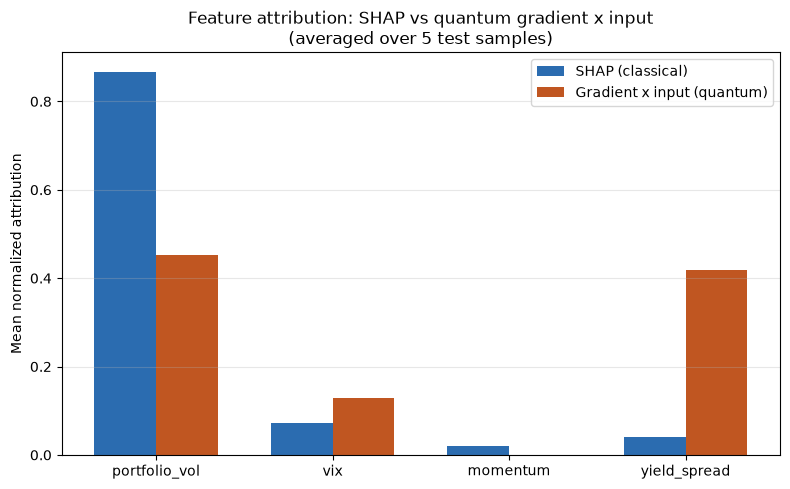

Saved figure: figures/06_attribution_comparison.png


In [7]:
shap_mean = shap_norm.mean(axis=0)
quantum_mean = quantum_norm.mean(axis=0)

x_pos = np.arange(len(selected_features))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x_pos - width/2, shap_mean, width, label='SHAP (classical)', color='#2b6cb0')
ax.bar(x_pos + width/2, quantum_mean, width, label='Gradient x input (quantum)', color='#c05621')
ax.set_xticks(x_pos)
ax.set_xticklabels(selected_features)
ax.set_ylabel('Mean normalized attribution')
ax.set_title('Feature attribution: SHAP vs quantum gradient x input\n(averaged over 5 test samples)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.savefig('../figures/06_attribution_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/06_attribution_comparison.png")

## Rank correlation

In [8]:
from scipy.stats import spearmanr

shap_rank = pd.Series(shap_mean, index=selected_features).rank(ascending=False)
quantum_rank = pd.Series(quantum_mean, index=selected_features).rank(ascending=False)

print("Feature ranking (1 = most important):")
print(pd.DataFrame({'SHAP rank': shap_rank, 'Quantum rank': quantum_rank}))

corr, pvalue = spearmanr(shap_mean, quantum_mean)
print(f"\nSpearman rank correlation: {corr:.3f} (p={pvalue:.3f})")

Feature ranking (1 = most important):
               SHAP rank  Quantum rank
portfolio_vol        1.0           1.0
vix                  2.0           3.0
momentum             4.0           4.0
yield_spread         3.0           2.0

Spearman rank correlation: 0.800 (p=0.200)


**Interpretation**: the two methods agree on the top feature (`portfolio_vol`, rank 1 in both)
and on the bottom feature (`momentum`, rank 4 in both), but disagree on the middle two: SHAP
ranks `vix` above `yield_spread`, the quantum attribution ranks them the other way round. The
Spearman rank correlation is 0.800, but with only 4 features the p-value (0.200) is not
significant, so this number should be read as a rough directional signal, not a rigorous
statistic.

One specific and unexpected result: the quantum gradient x input attribution for `momentum`
(wire 2) is consistently on the order of 1e-16 across all 5 sampled days, effectively zero,
while `vix` (wire 1) and `yield_spread` (wire 3) both get non-trivial attribution. This is not
simply a distance-from-the-measured-qubit effect, since wire 3 is farther from the measured wire
0 than wire 2 is, yet wire 3's gradient is clearly non-zero. The specific cause was not
investigated further here; it is reported as an observed, reproducible property of this trained
circuit rather than explained. SHAP assigns `momentum` a small but non-zero weight for the same
samples, so this vanishing gradient looks like an artifact of this particular ansatz and trained
weights, not evidence that momentum carries no information.

Overlap between the two methods is partial, as expected going in. Perfect agreement between a
gradient-based quantum heuristic and a Shapley-value method built on a completely different
classical model was never a realistic outcome.